# RescueLink AI - Training & Evaluation Notebook
This notebook trains and evaluates the emergency classification model, visualizes accuracy, and saves artifacts.
This notebook will guide you step by step:
1. Load the dataset
2. Tokenize the text
3. Train the model
4. Evaluate accuracy
5. Visualize results



In [1]:
# Standard library
import os
import ast
import json
import time

# Data handling
import pandas as pd
import numpy as np

# PyTorch
import torch
from torch.utils.data import DataLoader

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Transformers (multilingual backbone + tokenizer)
from transformers import AutoTokenizer

# Scikit-learn utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    hamming_loss,
    precision_recall_fscore_support,
    accuracy_score
)

# Project modules
from models.emergency_classifier import EmergencyClassifier
from training.train import EmergencyDataset, set_seed, best_threshold_from_probs

## Step 0: Runtime Config and Latest Model Check

Before training, define the shared runtime config and check whether `models/emergency_model.pt` exists.
- If a compatible checkpoint exists, we can resume from it.
- If not, we initialize a fresh model.
- This notebook now uses `data/emergency_dataset.csv` to match `training/train.py`.

In [3]:
MODEL_PATH = "models/emergency_model.pt"
META_PATH = "models/label_meta.json"
DATASET_PATH = "data/emergency_dataset.csv"

BACKBONE = "xlm-roberta-base"
MAX_LENGTH = 128
TRAIN_SPLIT = 0.8
SUBSAMPLE_FRACTION = 1.0  # Use 1.0 for full-data final validation runs
EPOCHS = 10
PATIENCE = 3
LR = 5e-5
WEIGHT_DECAY = 0.01
DROPOUT = 0.3
LABEL_SMOOTHING = 0.1
TYPE_LOSS_WEIGHT = 1.0
SEVERITY_LOSS_WEIGHT = 1.0
SCHEDULER_GAMMA = 0.5
SCHEDULER_STEP_SIZE = 2
TYPE_THRESHOLD_MIN = 0.2
TYPE_THRESHOLD_MAX = 0.7
TYPE_THRESHOLD_STEP = 0.05
EVAL_MAX_BATCHES = None  # Set an int (e.g., 20) for a quick partial evaluation pass
SEED = 999

set_seed(SEED)

def expected_labels_from_dataset(dataset_path):
    df_arch = pd.read_csv(dataset_path)
    df_arch["incident_types"] = df_arch["incident_types"].apply(ast.literal_eval)
    df_arch["type_labels"] = df_arch["type_labels"].apply(ast.literal_eval)

    incident_idx_to_name = {}
    severity_idx_to_name = {}
    for _, row in df_arch.iterrows():
        for name, idx in zip(row["incident_types"], row["type_labels"]):
            incident_idx_to_name[int(idx)] = name
        severity_idx_to_name[int(row["severity_label"])] = row["severity"]

    incident = [incident_idx_to_name[i] for i in sorted(incident_idx_to_name.keys())]
    severity = [severity_idx_to_name[i] for i in sorted(severity_idx_to_name.keys())]
    return incident, severity

EXPECTED_INCIDENT_TYPES, EXPECTED_SEVERITY_LABELS = expected_labels_from_dataset(DATASET_PATH)

def load_metadata():
    if os.path.exists(META_PATH):
        with open(META_PATH, "r", encoding="utf-8") as f:
            return json.load(f)
    checkpoint = torch.load(MODEL_PATH, map_location="cpu")
    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        return {
            "incident_type_labels": checkpoint.get("incident_type_labels"),
            "severity_labels": checkpoint.get("severity_labels"),
            "backbone": checkpoint.get("backbone", BACKBONE),
            "threshold": checkpoint.get("threshold", 0.5),
        }
    raise ValueError("Metadata not found.")

def remap_head(state_dict, head_prefix, from_labels, to_labels):
    if from_labels == to_labels:
        return state_dict

    label_to_old_index = {label: i for i, label in enumerate(from_labels)}
    order = [label_to_old_index[label] for label in to_labels]

    w_key = f"{head_prefix}.weight"
    b_key = f"{head_prefix}.bias"

    if w_key in state_dict:
        state_dict[w_key] = state_dict[w_key][order, :]
    if b_key in state_dict:
        state_dict[b_key] = state_dict[b_key][order]
    return state_dict

if os.path.exists(MODEL_PATH):
    try:
        meta = load_metadata()
        tokenizer = AutoTokenizer.from_pretrained(meta.get("backbone", BACKBONE))
        architecture_match = (
            meta["incident_type_labels"] == EXPECTED_INCIDENT_TYPES and
            meta["severity_labels"] == EXPECTED_SEVERITY_LABELS
        )

        if architecture_match:
            model = EmergencyClassifier(
                num_incident_types=len(meta["incident_type_labels"]),
                num_severity_classes=len(meta["severity_labels"]),
                backbone=meta.get("backbone", BACKBONE),
            )
            checkpoint = torch.load(MODEL_PATH, map_location="cpu")
            state_dict = checkpoint.get("model_state_dict") if isinstance(checkpoint, dict) else checkpoint
            model.load_state_dict(state_dict)
            model.eval()
            print("Loaded existing model with compatible architecture")
        else:
            same_incident_set = set(meta["incident_type_labels"]) == set(EXPECTED_INCIDENT_TYPES)
            same_severity_set = set(meta["severity_labels"]) == set(EXPECTED_SEVERITY_LABELS)

            if same_incident_set and same_severity_set:
                print("Label set is compatible but order changed; remapping checkpoint heads")
                checkpoint = torch.load(MODEL_PATH, map_location="cpu")
                state_dict = checkpoint.get("model_state_dict") if isinstance(checkpoint, dict) else checkpoint

                state_dict = remap_head(
                    state_dict,
                    head_prefix="type_classifier",
                    from_labels=meta["incident_type_labels"],
                    to_labels=EXPECTED_INCIDENT_TYPES,
                )
                state_dict = remap_head(
                    state_dict,
                    head_prefix="severity_classifier",
                    from_labels=meta["severity_labels"],
                    to_labels=EXPECTED_SEVERITY_LABELS,
                )

                model = EmergencyClassifier(
                    num_incident_types=len(EXPECTED_INCIDENT_TYPES),
                    num_severity_classes=len(EXPECTED_SEVERITY_LABELS),
                    backbone=meta.get("backbone", BACKBONE),
                )
                model.load_state_dict(state_dict)
                model.eval()

                meta = {
                    "incident_type_labels": EXPECTED_INCIDENT_TYPES,
                    "severity_labels": EXPECTED_SEVERITY_LABELS,
                    "backbone": meta.get("backbone", BACKBONE),
                    "threshold": meta.get("threshold", 0.5),
                }
                print("Loaded checkpoint after remapping label order")
            else:
                print("Architecture mismatch, training fresh model")
                print(f"Checkpoint incident labels: {meta['incident_type_labels']}")
                print(f"Dataset incident labels:    {EXPECTED_INCIDENT_TYPES}")
                meta = {
                    "incident_type_labels": EXPECTED_INCIDENT_TYPES,
                    "severity_labels": EXPECTED_SEVERITY_LABELS,
                    "backbone": BACKBONE,
                    "threshold": 0.5,
                }
                model = None
    except Exception as e:
        print(f"Load error: {e}, training fresh")
        meta = {
            "incident_type_labels": EXPECTED_INCIDENT_TYPES,
            "severity_labels": EXPECTED_SEVERITY_LABELS,
            "backbone": BACKBONE,
            "threshold": 0.5,
        }
        tokenizer = AutoTokenizer.from_pretrained(BACKBONE)
        model = None
else:
    print("No saved model, training fresh")
    meta = {
        "incident_type_labels": EXPECTED_INCIDENT_TYPES,
        "severity_labels": EXPECTED_SEVERITY_LABELS,
        "backbone": BACKBONE,
        "threshold": 0.5,
    }
    tokenizer = AutoTokenizer.from_pretrained(BACKBONE)
    model = None

print(f"Dataset path: {DATASET_PATH}")
print(f"Architecture: {len(meta['incident_type_labels'])} incident types, {len(meta['severity_labels'])} severity levels")
print(f"Labels: {meta['incident_type_labels']}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded existing model with compatible architecture
Dataset path: data/emergency_dataset.csv
Architecture: 6 incident types, 4 severity levels
Labels: ['Fire', 'Crime', 'Accident', 'Medical', 'Natural Disaster', 'Other']


## Step 1: Load the Dataset
Run the next cell to load the emergency dataset from `data/emergency_dataset.csv`.
The split is stratified by `severity_label` for stable validation metrics.

In [4]:
df = pd.read_csv(DATASET_PATH)

df["incident_types"] = df["incident_types"].apply(ast.literal_eval)
df["type_labels"] = df["type_labels"].apply(ast.literal_eval)
df["severity_label"] = df["severity_label"].astype(int)

train_df, val_df = train_test_split(
    df,
    train_size=TRAIN_SPLIT,
    random_state=SEED,
    stratify=df["severity_label"],
)

original_train_size = len(train_df)
if 0.0 < SUBSAMPLE_FRACTION < 1.0:
    train_df, _ = train_test_split(
        train_df,
        train_size=SUBSAMPLE_FRACTION,
        random_state=SEED,
        stratify=train_df["severity_label"],
    )
    print(f"Subsampling enabled: using {SUBSAMPLE_FRACTION:.2f} of train split")
else:
    print("Subsampling disabled: using full train split")

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
sampled_train_size = len(train_df)
effective_fraction = sampled_train_size / max(1, original_train_size)

print("DATASET SUMMARY")
print(f"Original train size (before subsample): {original_train_size}")
print(f"Train size used: {sampled_train_size}")
print(f"Validation size: {len(val_df)}")
print(f"Total raw rows: {len(df)}")
print(f"Effective train fraction: {effective_fraction:.2f}")

if "lang" in train_df.columns:
    print("\nLanguage Distribution (Train):")
    print(train_df["lang"].value_counts())

severity_map = {0: "Green", 1: "Yellow", 2: "Red", 3: "Black"}
print("\nSeverity Distribution (Train):")
for label in sorted(train_df["severity_label"].unique()):
    count = (train_df["severity_label"] == label).sum()
    print(f"  {severity_map[label]}: {count} ({count/len(train_df)*100:.1f}%)")

Subsampling disabled: using full train split
DATASET SUMMARY
Original train size (before subsample): 12000
Train size used: 12000
Validation size: 3000
Total raw rows: 15000
Effective train fraction: 1.00

Language Distribution (Train):
lang
fil    9558
en     2442
Name: count, dtype: int64

Severity Distribution (Train):
  Green: 3069 (25.6%)
  Yellow: 2998 (25.0%)
  Red: 3050 (25.4%)
  Black: 2883 (24.0%)


In [5]:
print("=" * 60)
print("DATASET DIAGNOSTICS")
print("=" * 60)
print(f"Dataset size: {len(df)}")

print(f"Avg text length: {df['text'].str.len().mean():.0f} chars")
print(f"Min text length: {df['text'].str.len().min()} chars")
print(f"Max text length: {df['text'].str.len().max()} chars")

print(f"\nAvg labels per row: {df['type_labels'].apply(len).mean():.2f}")
print("Label distribution:")
label_counts = df["type_labels"].apply(len).value_counts().sort_index()
for num_labels, count in label_counts.items():
    print(f"  {num_labels} label(s): {count} rows ({count/len(df)*100:.1f}%)")

print(f"\n{'DEVICE INFO':^60}")
if torch.cuda.is_available():
    print(f"GPU memory used: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
    print(f"GPU memory reserved: {torch.cuda.memory_reserved() / 1e9:.2f} GB")
    print(f"GPU device: {torch.cuda.get_device_name(0)}")
else:
    print("Running on CPU")
print("=" * 60)

DATASET DIAGNOSTICS
Dataset size: 15000
Avg text length: 49 chars
Min text length: 16 chars
Max text length: 105 chars

Avg labels per row: 1.30
Label distribution:
  1 label(s): 10536 rows (70.2%)
  2 label(s): 4464 rows (29.8%)

                        DEVICE INFO                         
GPU memory used: 0.00 GB
GPU memory reserved: 0.00 GB
GPU device: NVIDIA GeForce RTX 4050 Laptop GPU


## Step 2: Tokenization
Run this cell to convert text into numerical tokens using XLM-RoBERTa.
This prepares train and validation sets for the classifier.

In [6]:
tokenizer = AutoTokenizer.from_pretrained(meta.get("backbone", BACKBONE))

train_encodings = tokenizer(
    train_df["text"].tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LENGTH,
 )
val_encodings = tokenizer(
    val_df["text"].tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LENGTH,
 )

In [7]:
train_dataset = EmergencyDataset(
    train_encodings,
    train_df["type_labels"].tolist(),
    train_df["severity_label"].tolist(),
    num_types=len(meta["incident_type_labels"]),
)
val_dataset = EmergencyDataset(
    val_encodings,
    val_df["type_labels"].tolist(),
    val_df["severity_label"].tolist(),
    num_types=len(meta["incident_type_labels"]),
)

BATCH_SIZE = 32 if torch.cuda.is_available() else 8
PIN_MEMORY = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=PIN_MEMORY,
    num_workers=0,
 )
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=PIN_MEMORY,
    num_workers=0,
 )

print(f"Batch size: {BATCH_SIZE}")

Batch size: 32


## Step 3: Training Loop
Run this cell to train the EmergencyClassifier model.
You’ll see training and validation loss after each epoch.


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = torch.cuda.is_available()

model = EmergencyClassifier(
    num_incident_types=len(meta["incident_type_labels"]),
    num_severity_classes=len(meta["severity_labels"]),
    backbone=meta.get("backbone", BACKBONE),
).to(device)
model.dropout = torch.nn.Dropout(DROPOUT)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=SCHEDULER_STEP_SIZE, gamma=SCHEDULER_GAMMA)
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

bce_loss = torch.nn.BCEWithLogitsLoss()
ce_loss_severity = torch.nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

train_losses, val_losses = [], []
best_score = -1.0
best_state = None
wait = 0
training_start = time.perf_counter()
epochs_completed = 0

for epoch in range(EPOCHS):
    epoch_start = time.perf_counter()
    model.train()
    total_loss = 0.0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        type_labels = batch["type_labels"].to(device)
        severity_labels = batch["severity_labels"].to(device)

        with torch.amp.autocast(device_type="cuda", enabled=use_amp):
            outputs = model(input_ids, attention_mask)
            loss_type = bce_loss(outputs["type_logits"], type_labels)
            loss_severity = ce_loss_severity(outputs["severity_logits"], severity_labels)
            loss = TYPE_LOSS_WEIGHT * loss_type + SEVERITY_LOSS_WEIGHT * loss_severity

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += float(loss.item())

    train_loss = total_loss / max(1, len(train_loader))
    train_losses.append(train_loss)

    model.eval()
    val_loss_sum = 0.0
    y_type_true, y_type_probs = [], []
    y_sev_true, y_sev_pred = [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            type_labels = batch["type_labels"].to(device)
            severity_labels = batch["severity_labels"].to(device)

            with torch.amp.autocast(device_type="cuda", enabled=use_amp):
                outputs = model(input_ids, attention_mask)
                loss_type = bce_loss(outputs["type_logits"], type_labels)
                loss_severity = ce_loss_severity(outputs["severity_logits"], severity_labels)
                val_loss_sum += float((loss_type + loss_severity).item())

            type_probs = torch.sigmoid(outputs["type_logits"]).cpu().numpy()
            sev_pred = torch.argmax(outputs["severity_logits"], dim=1).cpu().numpy()

            y_type_true.append(type_labels.cpu().numpy())
            y_type_probs.append(type_probs)
            y_sev_true.append(severity_labels.cpu().numpy())
            y_sev_pred.append(sev_pred)

    val_loss = val_loss_sum / max(1, len(val_loader))
    val_losses.append(val_loss)

    y_type_true_arr = np.vstack(y_type_true).astype(int)
    y_type_probs_arr = np.vstack(y_type_probs)
    y_type_pred_arr = (y_type_probs_arr >= 0.5).astype(int)
    y_sev_true_arr = np.concatenate(y_sev_true)
    y_sev_pred_arr = np.concatenate(y_sev_pred)

    val_type_f1 = f1_score(y_type_true_arr, y_type_pred_arr, average="micro", zero_division=0)
    val_sev_acc = accuracy_score(y_sev_true_arr, y_sev_pred_arr)
    score = 0.5 * (val_type_f1 + val_sev_acc)

    if score > best_score:
        best_score = score
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1

    scheduler.step()
    epoch_time_sec = time.perf_counter() - epoch_start
    epochs_completed = epoch + 1
    print(
        f"Epoch {epoch+1}/{EPOCHS} | LR: {scheduler.get_last_lr()[0]:.6f} | "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"Val F1@0.5: {val_type_f1:.4f} | Val Sev Acc: {val_sev_acc:.4f} | "
        f"Epoch Time: {epoch_time_sec:.2f}s"
    )

    if wait >= PATIENCE:
        print(f"Early stopping at epoch {epoch+1}")
        break

if best_state is not None:
    model.load_state_dict(best_state)
print("Best validation checkpoint restored.")

total_training_time_sec = time.perf_counter() - training_start
avg_epoch_time_sec = total_training_time_sec / max(1, epochs_completed)
print(f"Total training time: {total_training_time_sec:.2f}s")
print(f"Average epoch time: {avg_epoch_time_sec:.2f}s over {epochs_completed} epoch(s)")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/10 | LR: 0.000050 | Train Loss: 1.9674 | Val Loss: 1.9261 | Val F1@0.5: 0.0000 | Val Sev Acc: 0.2500 | Epoch Time: 292.88s
Epoch 2/10 | LR: 0.000025 | Train Loss: 1.9389 | Val Loss: 1.9138 | Val F1@0.5: 0.0000 | Val Sev Acc: 0.2560 | Epoch Time: 296.86s
Epoch 3/10 | LR: 0.000025 | Train Loss: 1.9269 | Val Loss: 1.9112 | Val F1@0.5: 0.0000 | Val Sev Acc: 0.2557 | Epoch Time: 295.70s
Epoch 4/10 | LR: 0.000013 | Train Loss: 1.9297 | Val Loss: 1.9104 | Val F1@0.5: 0.0000 | Val Sev Acc: 0.2543 | Epoch Time: 296.78s
Epoch 5/10 | LR: 0.000013 | Train Loss: 1.9263 | Val Loss: 1.9121 | Val F1@0.5: 0.0000 | Val Sev Acc: 0.2543 | Epoch Time: 296.63s
Early stopping at epoch 5
Best validation checkpoint restored.
Total training time: 1479.05s
Average epoch time: 295.81s over 5 epoch(s)


## Step 4: Accuracy & Metrics
Run this cell to evaluate the model on the validation set.
You’ll see precision, recall, and F1 scores.


In [9]:
y_true_types, y_true_severity = [], []
y_pred_types, y_pred_severity = [], []
y_type_probs_all = []

model.eval()
eval_use_amp = torch.cuda.is_available()
eval_start = time.perf_counter()
eval_max_batches = globals().get("EVAL_MAX_BATCHES", None)

with torch.no_grad():
    for batch_idx, batch in enumerate(val_loader, start=1):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        type_labels = batch["type_labels"].cpu().numpy().astype(int)
        severity_labels = batch["severity_labels"].cpu().numpy().astype(int)

        with torch.amp.autocast(device_type="cuda", enabled=eval_use_amp):
            outputs = model(input_ids, attention_mask)

        type_probs = torch.sigmoid(outputs["type_logits"]).detach().cpu().numpy()
        preds_severity = torch.argmax(outputs["severity_logits"], dim=1).detach().cpu().numpy()

        y_true_types.extend(type_labels)
        y_true_severity.extend(severity_labels)
        y_type_probs_all.extend(type_probs)
        y_pred_severity.extend(preds_severity)

        if eval_max_batches is not None and batch_idx >= eval_max_batches:
            print(f"Quick eval mode: stopped after {batch_idx} batch(es)")
            break

y_true_types_arr = np.array(y_true_types).astype(int)
y_type_probs_arr = np.array(y_type_probs_all)

best_threshold_info = best_threshold_from_probs(
    y_true=y_true_types_arr,
    y_probs=y_type_probs_arr,
    t_min=TYPE_THRESHOLD_MIN,
    t_max=TYPE_THRESHOLD_MAX,
    t_step=TYPE_THRESHOLD_STEP,
)
selected_threshold = best_threshold_info["threshold"]

y_pred_types_arr = (y_type_probs_arr >= selected_threshold).astype(int)

type_f1_micro = f1_score(y_true_types_arr, y_pred_types_arr, average="micro", zero_division=0)
type_hamm = hamming_loss(y_true_types_arr, y_pred_types_arr)
sev_acc = accuracy_score(y_true_severity, y_pred_severity)

y_pred_types = y_pred_types_arr.tolist()

eval_elapsed = time.perf_counter() - eval_start
print(f"Selected threshold: {selected_threshold:.2f}")
print(f"Incident Type F1 (micro): {type_f1_micro:.4f}")
print(f"Incident Type Hamming Loss: {type_hamm:.4f}")
print(f"Severity Accuracy: {sev_acc:.4f}")
print(f"Evaluation time: {eval_elapsed:.2f}s")
print(classification_report(y_true_severity, y_pred_severity))

Selected threshold: 0.20
Incident Type F1 (micro): 0.2592
Incident Type Hamming Loss: 0.4110
Severity Accuracy: 0.2560
Evaluation time: 8.09s
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       767
           1       0.25      1.00      0.40       750
           2       0.00      0.00      0.00       763
           3       0.82      0.03      0.05       720

    accuracy                           0.26      3000
   macro avg       0.27      0.26      0.11      3000
weighted avg       0.26      0.26      0.11      3000



c:\Users\Aaron\GitHub Repos\RescueLink\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Aaron\GitHub Repos\RescueLink\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Aaron\GitHub Repos\RescueLink\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

## Step 5: Confusion Matrices & Loss Curves
Run these cells to visualize:
- Where the model misclassifies (confusion matrices)
- How training progressed (loss curves)


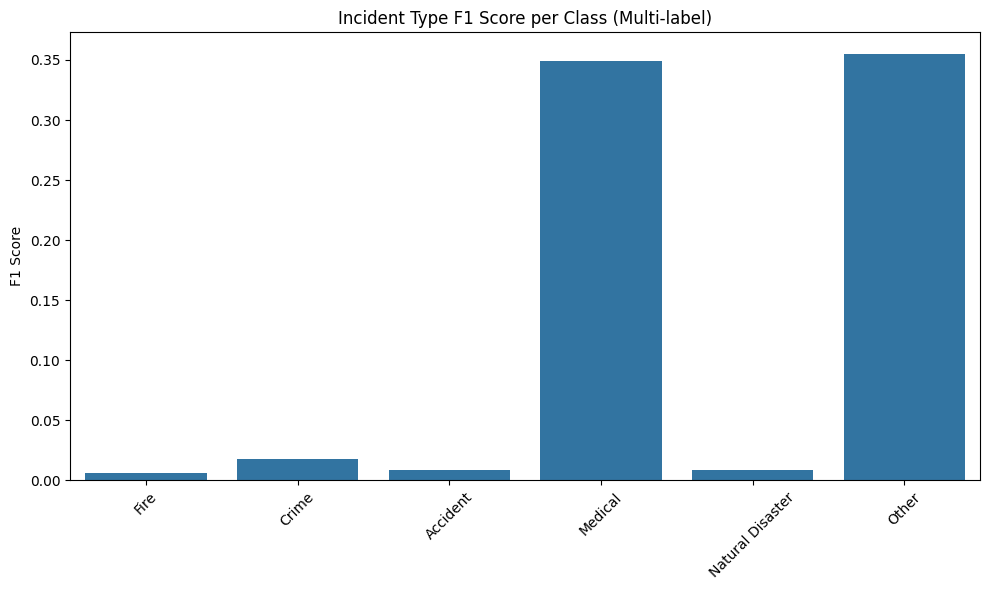

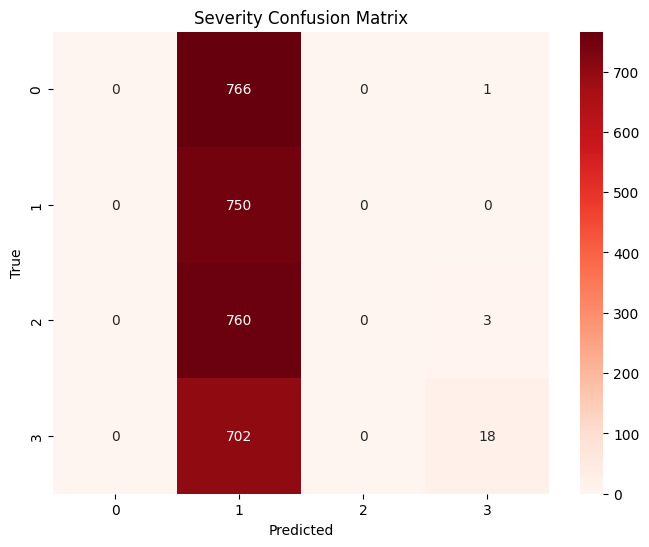

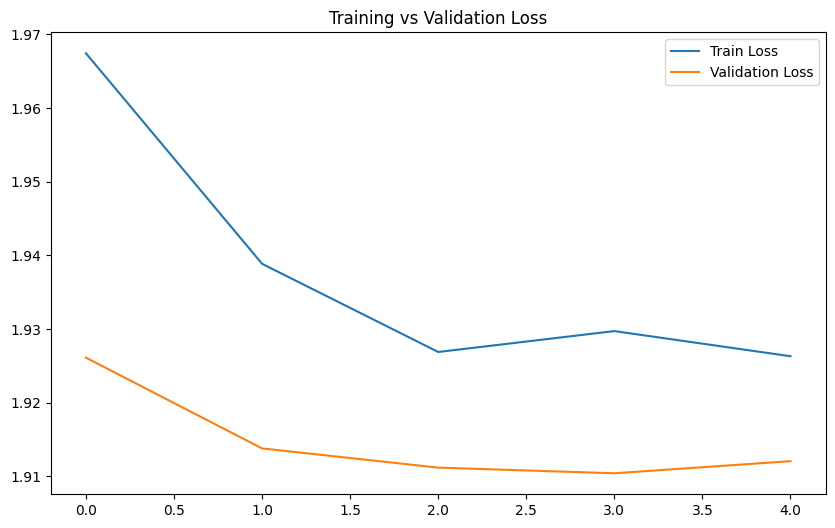

In [10]:
# --- Incident Types (multi-label) ---
y_true_types_arr = np.array(y_true_types)
y_pred_types_arr = np.array(y_pred_types)

# Per-class metrics for incident types
precisions, recalls, f1s, _ = precision_recall_fscore_support(
    y_true_types_arr, y_pred_types_arr, average=None
)

incident_type_labels = {i: label for i, label in enumerate(meta["incident_type_labels"])}

plt.figure(figsize=(10,6))
sns.barplot(x=list(incident_type_labels.values()), y=f1s)
plt.title("Incident Type F1 Score per Class (Multi-label)")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Severity (single-label) ---
cm_severity = confusion_matrix(y_true_severity, y_pred_severity)
plt.figure(figsize=(8,6))
sns.heatmap(cm_severity, annot=True, fmt="d", cmap="Reds")
plt.title("Severity Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# --- Loss curves ---
plt.figure(figsize=(10,6))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

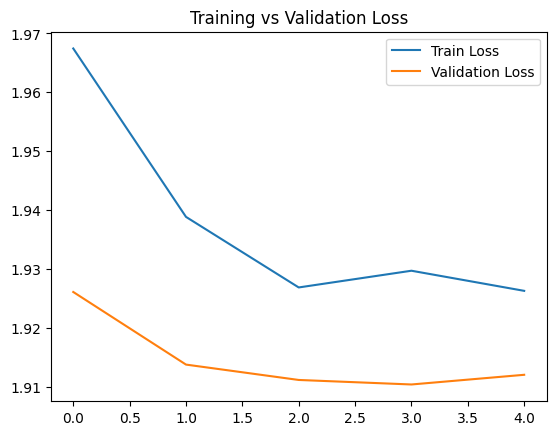

In [11]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()


In [12]:
# Step 5.5: Over/Under-fit quick check
import numpy as np

if len(train_losses) >= 2 and len(val_losses) >= 2:
    # Recent loss trend
    train_slope = np.polyfit(range(len(train_losses)), train_losses, 1)[0]
    val_slope = np.polyfit(range(len(val_losses)), val_losses, 1)[0]
    gap = val_losses[-1] - train_losses[-1]
    gap_pct = gap / (train_losses[-1] + 1e-8) * 100

    print("=== Fit Diagnostic ===")
    print(f"Train loss last: {train_losses[-1]:.2f}")
    print(f"Val loss last:   {val_losses[-1]:.2f}")
    print(f"Gap: {gap:.2f} ({gap_pct:.1f}%)")
    print(f"Train slope: {train_slope:.2f} per epoch")
    print(f"Val slope:   {val_slope:.2f} per epoch")

    if gap_pct > 30 and val_slope < 0:
        status = "Possible overfit: val > train with narrowing trend"
    elif gap_pct > 30 and val_slope >= 0:
        status = "Overfit likely: val > train and not improving"
    elif gap_pct < -10:
        status = "Underfit unlikely: val < train (rare)"
    else:
        status = "Healthy fit"
    print(f"Status: {status}")
else:
    print("Not enough epochs to assess fit.")

=== Fit Diagnostic ===
Train loss last: 1.93
Val loss last:   1.91
Gap: -0.01 (-0.7%)
Train slope: -0.01 per epoch
Val slope:   -0.00 per epoch
Status: Healthy fit


## Step 6: Save Best Checkpoint and Metadata
After training and threshold calibration, save the best model state into `models/emergency_model.pt`, and write matching metadata to `models/label_meta.json`.

In [13]:
if "selected_threshold" not in globals():
    selected_threshold = meta.get("threshold", 0.5)

checkpoint = {
    "model_state_dict": model.state_dict(),
    "incident_type_labels": meta["incident_type_labels"],
    "severity_labels": meta["severity_labels"],
    "backbone": meta.get("backbone", BACKBONE),
    "threshold": float(selected_threshold),
}
torch.save(checkpoint, MODEL_PATH)

meta_payload = {
    "incident_type_labels": meta["incident_type_labels"],
    "severity_labels": meta["severity_labels"],
    "backbone": meta.get("backbone", BACKBONE),
    "threshold": float(selected_threshold),
}
with open(META_PATH, "w", encoding="utf-8") as f:
    json.dump(meta_payload, f, ensure_ascii=True, indent=2)

print(f"Model checkpoint saved to: {MODEL_PATH}")
print(f"Metadata saved to: {META_PATH}")
print(f"Saved threshold: {float(selected_threshold):.2f}")

Model checkpoint saved to: models/emergency_model.pt
Metadata saved to: models/label_meta.json
Saved threshold: 0.20


In [14]:
print("Quick metrics from completed training cell")
if "val_type_f1" in globals() and "val_sev_acc" in globals():
    print(f"Last epoch val incident F1@0.5: {val_type_f1:.4f}")
    print(f"Last epoch val severity acc: {val_sev_acc:.4f}")
else:
    print("No val metrics found in current kernel state.")

if "best_score" in globals():
    print(f"Best blended score seen: {best_score:.4f}")

if "train_losses" in globals() and "val_losses" in globals() and len(train_losses) and len(val_losses):
    print(f"Epochs completed: {len(train_losses)}")
    print(f"Last train loss: {train_losses[-1]:.4f}")
    print(f"Last val loss: {val_losses[-1]:.4f}")

if "total_training_time_sec" in globals() and "avg_epoch_time_sec" in globals():
    print(f"Total training time: {total_training_time_sec:.2f}s")
    print(f"Avg epoch time: {avg_epoch_time_sec:.2f}s")

Quick metrics from completed training cell
Last epoch val incident F1@0.5: 0.0000
Last epoch val severity acc: 0.2543
Best blended score seen: 0.1280
Epochs completed: 5
Last train loss: 1.9263
Last val loss: 1.9121
Total training time: 1479.05s
Avg epoch time: 295.81s


In [15]:
snapshot = {
    "seed": SEED if "SEED" in globals() else None,
    "subsample_fraction": SUBSAMPLE_FRACTION if "SUBSAMPLE_FRACTION" in globals() else None,
    "eval_max_batches": EVAL_MAX_BATCHES if "EVAL_MAX_BATCHES" in globals() else None,
    "incident_f1_micro": float(type_f1_micro) if "type_f1_micro" in globals() else None,
    "incident_hamming_loss": float(type_hamm) if "type_hamm" in globals() else None,
    "severity_accuracy": float(sev_acc) if "sev_acc" in globals() else None,
    "selected_threshold": float(selected_threshold) if "selected_threshold" in globals() else None,
    "best_blended_score": float(best_score) if "best_score" in globals() else None,
    "last_epoch_val_f1_at_0_5": float(val_type_f1) if "val_type_f1" in globals() else None,
    "last_epoch_val_sev_acc": float(val_sev_acc) if "val_sev_acc" in globals() else None,
    "epochs_completed": int(epochs_completed) if "epochs_completed" in globals() else None,
    "total_training_time_sec": float(total_training_time_sec) if "total_training_time_sec" in globals() else None,
    "avg_epoch_time_sec": float(avg_epoch_time_sec) if "avg_epoch_time_sec" in globals() else None,
    "evaluation_time_sec": float(eval_elapsed) if "eval_elapsed" in globals() else None,
}
print(json.dumps(snapshot, indent=2))

{
  "seed": 999,
  "subsample_fraction": 1.0,
  "eval_max_batches": null,
  "incident_f1_micro": 0.2591628279591428,
  "incident_hamming_loss": 0.411,
  "severity_accuracy": 0.256,
  "selected_threshold": 0.2,
  "best_blended_score": 0.128,
  "last_epoch_val_f1_at_0_5": 0.0,
  "last_epoch_val_sev_acc": 0.25433333333333336,
  "epochs_completed": 5,
  "total_training_time_sec": 1479.0468205999932,
  "avg_epoch_time_sec": 295.80936411999863,
  "evaluation_time_sec": 8.086655199993402
}


In [16]:
from pathlib import Path
import re
import statistics

md_path = Path("Training Results.md")


def _fmt(value, digits=6):
    if value is None:
        return ""
    return f"{float(value):.{digits}f}"


def _fmt2(value):
    if value is None:
        return ""
    return f"{float(value):.2f}"


def build_seed_block(seed_value):
    return "\n".join([
        f"## Seed {seed_value}",
        f"- Incident F1 (micro): `{_fmt(type_f1_micro)}`",
        f"- Incident hamming loss: `{_fmt(type_hamm)}`",
        f"- Severity accuracy: `{_fmt(sev_acc)}`",
        f"- Selected threshold: `{_fmt(selected_threshold, 2)}`",
        f"- Best blended score: `{_fmt(best_score)}`",
        f"- Last epoch F1@0.5: `{_fmt(val_type_f1)}`",
        f"- Last epoch severity accuracy: `{_fmt(val_sev_acc)}`",
        f"- Epochs completed: `{int(epochs_completed)}`",
        f"- Total train time: `{_fmt2(total_training_time_sec)}s`",
        f"- Average epoch time: `{_fmt2(avg_epoch_time_sec)}s`",
        f"- Evaluation time: `{_fmt2(eval_elapsed)}s`",
        "- Notes: Auto-updated from notebook",
    ])


seed_value = int(SEED)

if not md_path.exists():
    raise FileNotFoundError("Training Results.md not found. Create it first.")

text = md_path.read_text(encoding="utf-8")
seed_header = f"## Seed {seed_value}"
seed_block = build_seed_block(seed_value)

start = text.find(seed_header)
if start != -1:
    next_seed = text.find("\n## Seed ", start + len(seed_header))
    next_agg = text.find("\n## Aggregation", start + len(seed_header))
    end_candidates = [x for x in [next_seed, next_agg] if x != -1]
    end = min(end_candidates) if end_candidates else len(text)
    text = text[:start] + seed_block + text[end:]
else:
    agg_start = text.find("\n## Aggregation")
    insert_at = agg_start if agg_start != -1 else len(text)
    text = text[:insert_at].rstrip() + "\n\n" + seed_block + "\n\n" + text[insert_at:].lstrip()

seed_section_pattern = re.compile(r"## Seed (\d+)\n((?:- .*\n)+)")
seed_metrics = []
for m in seed_section_pattern.finditer(text):
    seed_num = int(m.group(1))
    block = m.group(2)
    f1_match = re.search(r"Incident F1 \(micro\): `([0-9.]+)`", block)
    sev_match = re.search(r"Severity accuracy: `([0-9.]+)`", block)
    if f1_match and sev_match:
        seed_metrics.append((seed_num, float(f1_match.group(1)), float(sev_match.group(1))))

if seed_metrics:
    f1_vals = [x[1] for x in seed_metrics]
    sev_vals = [x[2] for x in seed_metrics]
    f1_mean = statistics.mean(f1_vals)
    f1_std = statistics.pstdev(f1_vals) if len(f1_vals) > 1 else 0.0
    sev_mean = statistics.mean(sev_vals)
    sev_std = statistics.pstdev(sev_vals) if len(sev_vals) > 1 else 0.0
    pass_text = "PASS" if (f1_mean >= 0.99 and sev_mean >= 0.99) else "FAIL"

    text = re.sub(r"- Incident F1 mean:.*", f"- Incident F1 mean: `{f1_mean:.6f}`", text)
    text = re.sub(r"- Incident F1 std:.*", f"- Incident F1 std: `{f1_std:.6f}`", text)
    text = re.sub(r"- Severity accuracy mean:.*", f"- Severity accuracy mean: `{sev_mean:.6f}`", text)
    text = re.sub(r"- Severity accuracy std:.*", f"- Severity accuracy std: `{sev_std:.6f}`", text)
    text = re.sub(
        r"- Pass/Fail \(>= 0.99 on both metrics\):.*",
        f"- Pass/Fail (>= 0.99 on both metrics): `{pass_text}`",
        text,
    )

md_path.write_text(text, encoding="utf-8")
print(f"Updated {md_path} for seed {seed_value}.")

Updated Training Results.md for seed 999.
